In [1]:
import os
import re
import csv
import pandas as pd
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

- source_file: txt file name.
- source_path: path in the original source.
- category: {INTRO, BACK}
- keywords: keywords or short phrases
- key_phrases: short phrases (not as accurate)
- snippet: piece of text with length between 250 to 1000 words
- confidence: {high, }

# Carga de Archivos

In [2]:
from google.colab import auth
from google.auth import default
from googleapiclient.discovery import build
import io
from googleapiclient.http import MediaIoBaseDownload

# 1. Authenticate your Google account
auth.authenticate_user()
creds, _ = default()

# 2. Build the Drive API client
drive_service = build('drive', 'v3', credentials=creds)
print("Successfully connected to the Google Drive API!")

Successfully connected to the Google Drive API!


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

# Please update these paths with your actual file locations in Google Drive
# unified_csv = '/content/data/etiquetas_manuales/etiquetas_manuales_unificadas.csv'
unified_csv = './etiquetas_manuales_unificadas.csv'
full_contr_csv = './validacion_CONTR_edwin(2374).csv'
previous_csv = './auto_labeled_output.csv'
# text_folder_path = '/content/drive/MyDrive/core'
# text_folder_path = '/content/drive/MyDrive/MasterAI/DespliegueSoluciones/datos/copied_originals/INTRO'
# text_folder_path = 'https://drive.google.com/drive/folders/1v90N8M6Ld3a76hlNXyQw7jhpX_fqY3Yc?usp=drive_link'

## Configuración W&B

In [4]:
#Instalar W&B
!pip install wandb -q

In [5]:
#Login  W&B
from google.colab import userdata
import wandb

wandb.login(key=userdata.get("WANDB_API_KEY"))


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: natamoncada10 (natamoncada10-universidad-de-los-andes) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
#Prueba mínima de conexión  W&B
run = wandb.init(
    project="maia-flag-document-analysis",
    entity="natamoncada10-universidad-de-los-andes",
    name="test-connection-nata",
    tags=["test", "setup"],
    config={
        "purpose": "validar conexion inicial",
        "owner": "nata"
    }
)

wandb.log({"test_metric": 1.0})
wandb.finish()

test_metric,▁
test_metric,1


# Preparación del Dataset Combinado
> 🆕 **Celdas agregadas** — Unen los dos batches de autoetiquetado generados por Edwin, eliminan duplicados y submuestrean las clases con más de 2000 snippets para balancear el dataset antes del EDA y entrenamiento.

In [8]:
# [NUEVA CELDA] Union de batches con priorizacion de batch3 y batch4
# ==========================================
# Estrategia de Cristian:
# 1. Priorizar batch3 y batch4 (mejor calidad, regex mejorada)
# 2. Completar con batch1 y batch2 donde falten snippets
# 3. Agregar CONTR de Edwin
# 4. Eliminar duplicados
# ==========================================

import pandas as pd

COLS = ['source_file', 'category', 'snippet', 'word_count', 'matched_keywords', 'regex_score']
TARGET_PER_CLASS = 1800

# --- 1. Cargar todos los batches ---
batch1 = pd.read_csv('./auto_labeled_output.csv')[COLS]
batch2 = pd.read_csv('./auto_labeled_output_batch2.csv')[COLS]
batch3 = pd.read_csv('./auto_labeled_output_batch3.csv')[COLS]
batch4 = pd.read_csv('./auto_labeled_output_batch4.csv')[COLS]

print(f"Batch 1: {len(batch1)} snippets")
print(f"Batch 2: {len(batch2)} snippets")
print(f"Batch 3: {len(batch3)} snippets")
print(f"Batch 4: {len(batch4)} snippets")

# --- 2. Cargar y alinear CONTR de Edwin ---
contr_df = pd.read_csv('./train_test_1800_CONTR.csv')
contr_df['word_count'] = contr_df['snippet'].apply(lambda x: len(str(x).split()))
contr_df['matched_keywords'] = contr_df['keywords']
contr_df['regex_score'] = 0
contr_df = contr_df[COLS]
print(f"CONTR (Edwin): {len(contr_df)} snippets")

# --- 3. Priorizar batch3 y batch4 ---
# Estos tienen mejor calidad por las regex mejoradas y filtros de documentos
priority = pd.concat([batch3, batch4], ignore_index=True)
priority = priority.drop_duplicates(subset=['snippet'])

# --- 4. Complementar con batch1 y batch2 donde falten snippets ---
fallback = pd.concat([batch1, batch2], ignore_index=True)
fallback = fallback.drop_duplicates(subset=['snippet'])
# Excluir snippets que ya están en priority
fallback = fallback[~fallback['snippet'].isin(priority['snippet'])]

print("\nDistribucion en batches prioritarios (3+4):")
print(priority['category'].value_counts())

supplemented = []
for cat in priority['category'].unique():
    cat_priority = priority[priority['category'] == cat]
    needed = TARGET_PER_CLASS - len(cat_priority)
    if needed > 0:
        cat_fallback = fallback[fallback['category'] == cat].head(needed)
        supplemented.append(pd.concat([cat_priority, cat_fallback]))
        print(f"{cat}: {len(cat_priority)} priority + {len(cat_fallback)} fallback = {len(cat_priority)+len(cat_fallback)}")
    else:
        supplemented.append(cat_priority)
        print(f"{cat}: {len(cat_priority)} priority (no fallback needed)")

# Agregar categorias que solo estan en batch1/2 (si las hay)
cats_in_priority = set(priority['category'].unique())
cats_in_fallback = set(fallback['category'].unique())
missing_cats = cats_in_fallback - cats_in_priority
for cat in missing_cats:
    cat_data = fallback[fallback['category'] == cat].head(TARGET_PER_CLASS)
    supplemented.append(cat_data)
    print(f"{cat}: {len(cat_data)} (solo en fallback)")

combined = pd.concat(supplemented + [contr_df], ignore_index=True)
combined = combined.drop_duplicates(subset=['snippet'])

print(f"\nDataset combinado total: {len(combined)} snippets")
print("\nDistribucion final antes del submuestreo:")
print(combined['category'].value_counts())


Batch 1: 3911 snippets
Batch 2: 15117 snippets
Batch 3: 7155 snippets
Batch 4: 2571 snippets
CONTR (Edwin): 1800 snippets

Distribucion en batches prioritarios (3+4):
category
INTRO    2485
RES      1631
CONC     1501
BACK     1241
LIM      1129
DISC      924
METH      815
Name: count, dtype: int64
CONC: 1501 priority + 299 fallback = 1800
INTRO: 2485 priority (no fallback needed)
RES: 1631 priority + 169 fallback = 1800
DISC: 924 priority + 876 fallback = 1800
BACK: 1241 priority + 559 fallback = 1800
METH: 815 priority + 985 fallback = 1800
LIM: 1129 priority + 671 fallback = 1800

Dataset combinado total: 15085 snippets

Distribucion final antes del submuestreo:
category
INTRO    2485
CONC     1800
RES      1800
DISC     1800
BACK     1800
METH     1800
LIM      1800
CONTR    1800
Name: count, dtype: int64


In [9]:
# [NUEVA CELDA] Submuestreo para balancear clases
# ==========================================
# Las clases con mas de 2000 snippets se recortan a 2000.
# Las clases con menos se dejan como estan.
# ==========================================

MAX_PER_CLASS = 2000

balanced = (
    combined
    .groupby('category', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), MAX_PER_CLASS), random_state=42))
    .reset_index(drop=True)
)

balanced.to_csv('./training_ready_dataset.csv', index=False)

print("Distribucion final del dataset balanceado:")
print(balanced['category'].value_counts())
print(f"\nTotal de snippets: {len(balanced)}")
print("\nGuardado como training_ready_dataset.csv")


/tmp/ipykernel_587/3481887444.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), MAX_PER_CLASS), random_state=42))


Distribucion final del dataset balanceado:
category
INTRO    2000
BACK     1800
CONTR    1800
CONC     1800
DISC     1800
LIM      1800
METH     1800
RES      1800
Name: count, dtype: int64

Total de snippets: 14600

Guardado como training_ready_dataset.csv


# Autoclasificación de Segmentos

## Análisis de Frecuencias (Palabras/frases clave)

In [ ]:
# 1. Cargar el dataset consolidado
# Cambia el nombre del archivo si es necesario
try:
    df = pd.read_csv(unified_csv)
    print(f"Archivo cargado exitosamente. Total de fragmentos: {len(df)}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{unified_csv}'")
    exit()

print(f"Tamaño del dataframe consolidado {df.shape}")

# 2. Función para extraer y contar los términos más frecuentes
def obtener_top_terminos(df_subset, nombre_columna, top_n=20):
    todos_los_terminos = []

    # Recorrer cada fila de la columna especificada (ej. 'keywords')
    for texto in df_subset[nombre_columna].dropna():
        # Separar por comas o puntos y comas
        terminos = re.split(r'[,;]', str(texto))
        # Limpiar espacios en blanco y convertir a minúsculas
        todos_los_terminos.extend([t.strip().lower() for t in terminos if t.strip()])

    # Contar las frecuencias y devolver los N más comunes
    return Counter(todos_los_terminos).most_common(top_n)

# 3. Analizar automáticamente todas las categorías que existan en el CSV
categorias_encontradas = df['category'].unique()
print(f"\nCategorías detectadas en el archivo: {categorias_encontradas}")

# Diccionarios para guardar los resultados
resultados_keywords = {}
resultados_frases = {}

for categoria in categorias_encontradas:
    # Filtrar el dataframe por la categoría actual
    df_categoria = df[df['category'] == categoria]

    print(f"\n{'='*40}")
    print(f"ANÁLISIS PARA LA CATEGORÍA: {categoria} (Muestras: {len(df_categoria)})")
    print(f"{'='*40}")

    # Analizar la columna 'keywords'
    top_keywords = obtener_top_terminos(df_categoria, 'keywords', top_n=15)
    print("\n--- Top 15 Keywords ---")
    for termino, frecuencia in top_keywords:
        print(f" - {termino}: {frecuencia} veces")

    # Analizar la columna 'key_phrases' (si existe en el CSV)
    if 'key_phrases' in df.columns:
        top_phrases = obtener_top_terminos(df_categoria, 'key_phrases', top_n=10)
        print("\n--- Top 10 Key Phrases ---")
        for frase, frecuencia in top_phrases:
            print(f" - {frase}: {frecuencia} veces")

Archivo cargado exitosamente. Total de fragmentos: 1601
Tamaño del dataframe consolidado (1601, 7)

Categorías detectadas en el archivo: ['CONC' 'CONTR' 'LIM' 'INTRO' 'BACK' 'DISC' 'RES' 'METH']

ANÁLISIS PARA LA CATEGORÍA: CONC (Muestras: 200)

--- Top 15 Keywords ---
 - conclusiones: 28 veces
 - trabajo futuro: 18 veces
 - estudio: 11 veces
 - investigación: 10 veces
 - trabajo: 6 veces
 - estudiante: 5 veces
 - social: 4 veces
 - calidad: 4 veces
 - información: 4 veces
 - comunicación: 4 veces
 - educación: 4 veces
 - resultados: 4 veces
 - formación: 4 veces
 - crecimiento: 4 veces
 - recomendaciones: 4 veces

--- Top 10 Key Phrases ---
 - finalmente: 3 veces
 - presente trabajo: 2 veces
 - conclusiones: 2 veces
 - una transformación cultural: 1 veces
 - productos software de calidad de acuerdo con los requisitos: 1 veces
 - la transformación digital: 1 veces
 - como: integración continua: 1 veces
 - entrega continua: 1 veces
 - tratamiento quirúrgico: 1 veces
 - turf toe: 1 veces

## Construcción de Regex y AutoEtiquetado

In [ ]:
# ==========================================
# 1. CONFIGURACIÓN Y REGLAS DE AISLAMIENTO
# ==========================================

# Set to a small number (e.g., 10) for testing, then change to 2000 for the full run.
MIN_SNIPPETS_PER_CLASS = 1800
THRESHOLDS = {
    "DISC": 2,   # Mantenemos el mínimo para facilitar la recolección
    "CONC": 2,
    "INTRO": 3,  # altamente representada
    "LIM": 2,
    "BACK": 3,   # Subimos a 3 por el ruido de citaciones "et al."
    "METH": 4,   # Subimos a 4 porque tiene el score más alto (6.0) y ya superó la meta
    "RES": 4     # Subimos a 4 para reducir falsos positivos y canibalización
}
DEFAULT_THRESHOLD = 2
MIN_WORDS = 250
MAX_WORDS = 750

# Cargar los IDs que ya etiquetaste manualmente para IGNORARLOS en el autoetiquetado
# Esto asegura el cumplimiento de la regla de particionamiento estricto del documento.
df_validated = pd.read_csv(unified_csv)
manually_labeled_files = set(df_validated['source_file'].unique())

full_contr = pd.read_csv(full_contr_csv)
other_contr_files = set(full_contr['source_file'].unique()) - manually_labeled_files

previous_files = set(previous_auto_labeled_df['source_file'].unique())

ids_to_exclude = manually_labeled_files | other_contr_files | previous_files
print(f"IDs to exclude: {len(ids_to_exclude)}")

# 2. Define the patterns (Spanish keywords since the text is in Spanish)
regex_patterns = {
    "INTRO": re.compile(
        r'\b('
        r'objetivo\sgeneral|objetivo\sprincipal|el\sobjetivo\sde\s(?:este|esta)|'
        r'problema\sde\sinvestigaci[oó]n|introducci[oó]n|justificaci[oó]n|'
        r'prop[oó]sito\sprincipal|planteamiento\sdel\sproblema|'
        r'el\spresente\strabajo\s(?:aborda|tiene\scomo|se\scentra)|'
        r'la\sfinalidad\sde\s(?:este|esta)|hip[oó]tesis\sde\strabajo'
        r')\b',
        re.IGNORECASE
    ),
    "BACK": re.compile(
        r'\b('
        r'antecedentes|estado\sdel\sarte|trabajos\sprevios|'
        r'marco\ste[oó]rico|estudios\sprevios|investigaciones\sprevias|'
        r'revisi[oó]n\sbibliogr[aá]fica|literatura\scient[ií]fica|'
        r'trabajo\srelacionado|et\sal\.|seg[uú]n\s[A-Z][a-z]+|'
        r'estudios\santeriores|tradicionalmente'
        r')\b',
        re.IGNORECASE
    ),
    "METH": re.compile(
        r'\b('
        r'metodolog[íi]a|dise[ñn]o\smetodol[oó]gico|dise[ñn]o\sde\sinvestigaci[oó]n|'
        r'materiales\sy\sm[eé]todos|material\sy\sm[eé]todo|'
        r'poblaci[oó]n\sy\smuestra|tama[ñn]o\sde\s(?:la\s)?muestra|'
        r'criterios\sde\sinclusi[oó]n|criterios\sde\sexclusi[oó]n|'
        r'instrumentos\sde\srecolecci[oó]n|recolecci[oó]n\sde\sdatos|'
        r'an[aá]lisis\sestad[íi]stico|procedimiento\sexperimental|'
        r'enfoque\scuantitativo|enfoque\scualitativo|'
        r'investigaci[oó]n\s(?:cualitativa|cuantitativa)|'
        r'entrevistas\ssemiestructuradas|aplicaci[oó]n\sde\scuestionarios|'
        r'variables\sdependientes|variables\sindependientes'
        r')\b',
        re.IGNORECASE
    ),
    "RES": re.compile(
        r'\b('
        # Marcadores de sección y frases de apertura
        r'resultados|hallazgos|los\sresultados\smuestran|los\sresultados\sindican|'
        r'los\sresultados\sobtenidos|los\sdatos\smuestran|los\sanálisis\smuestran|'
        r'el\sanálisis\sindica|el\sanálisis\sreveló|'

        # Verbos de hallazgo en pasado (núcleo del reporte empírico)
        r'se\sencontró\sque|se\sobservó\sque|se\sidentificó|se\sdetectó|'
        r'se\sevidenció|se\sregistró|se\sobtuvieron|se\spudo\sobservar|'
        r'se\sapreció|arrojó|reveló|mostró|evidenció|'

        # Referencias a elementos visuales/tabulares
        r'como\sse\smuestra\sen|como\sse\sobserva\sen|como\sse\saprecia\sen|'
        r'en\sla\sfigura|en\sel\sgráfico|en\sla\stabla|en\sel\scuadro|'
        r'tal\scomo\sse\smuestra|véase\sla\sfigura|véase\sla\stabla|'

        # Lenguaje estadístico cuantitativo
        r'estadísticamente\ssignificativo|diferencia\ssignificativa|'
        r'no\ssignificativo|correlación\spositiva|correlación\snegativa|'
        r'valor\sde\sp|p\s[<>≤≥]\s0\.|intervalo\sde\sconfianza|'
        r'desviación\sestándar|error\sestándar|media\sde|mediana\sde|'
        r'coeficiente\sde|odds\sratio|razón\sde|frecuencia\srelativa|'

        # Cuantificaciones comparativas
        r'un\saumento\sde|una\sreducción\sde|una\sdisminución\sde|'
        r'superior\sa|inferior\sa|mayor\sque|menor\sque|'
        r'el\s\d+\s?%\sde|un\s\d+\s?%|aproximadamente\sel|'
        r'los\sresultados\sobtuvieron|los\sparticipantes\sreportaron'
        r')\b',
        re.IGNORECASE
    ),
    "DISC": re.compile(
        r'\b('
        # Marcadores de sección y frases de apertura
        r'discusi[oó]n|interpretaci[oó]n\sde\slos\sresultados|an[aá]lisis\scr[ií]tico|'

        # Comparación con literatura previa (Clave para DISC)
        r'en\sconcordancia\scon|coincide\scon|consistente\scon|'
        r'similar\sa\slo\sreportado|en\sl[ií]nea\scon|est[aá]\sde\sacuerdo\scon|'
        r'a\sdiferencia\sde|en\scontraste\scon|difiere\sde|contrario\sa|'
        r'mientras\sque\sotros\sautores|comparado\scon\sel\sestudio\sde|'

        # Evaluación y significado de los hallazgos
        r'estos\sresultados\ssugieren|estos\shallazgos|'
        r'esto\simplica\sque|esto\sindica\sque|lo\santerior\ssugiere|'
        r'apoya\sla\ship[oó]tesis|valida\snuestro\senfoque|corrobora\sque|'
        r'permite\sinferir|se\sinterpreta\scomo|da\scuenta\sde|'

        # Explicación de causas e incertidumbre
        r'esto\sse\sdebe\sa|podr[ií]a\sexplicarse\spor|atribuible\sa|'
        r'es\sposible\sque|podr[ií]a\sdeberse\sa|una\sposible\sexplicaci[oó]n|'
        r'probablemente\sdebido\sa|factores\sque\sinfluyeron|'
        r'a\sla\sluz\sde|bajo\sesta\sperspectiva|nos\slleva\sa\spensar|'

        # Implicaciones y relevancia
        r'relevancia\spara|impacto\sen|consecuencia\sde|'
        r'abre\snuevas\sperspectivas|demuestra\sla\simportancia\sde'
        r')\b',
        re.IGNORECASE
    ),
    # "CONTR": re.compile(r'\b(contribución|este\strabajo\saporta|nuestro\senfoque|se\spropone\sun\snuevo)\b', re.IGNORECASE),
    "LIM": re.compile(
        r'\b('
        r'limitaci[oó]n|limitaciones|no\sfue\sposible|no\ses\sposible|'
        r'sesgos\spotenciales|no\sse\spuede|sesgo|sesgado|sesgada|se\sdesconoce|imposibilidad|'
        r'no\spermite|no\spermite\sgeneralizar|fuera\sdel\salcance|no\sse\spudo|no\sse\spretende|'
        r'restricci[oó]n|restringe\sla|no\sgeneraliz|no\srepresenta|tama[ñn]o\sde\sla\smuestra|'
        r'tama[ñn]o\smuestral|muestra\speque[ñn]a|futuras\sinvestigaciones|'
        r'futuras\sl[íi]neas|l[íi]neas\sfuturas|investigaci[oó]n\sfutura|'
        r'trabajo\sfuturo|queda\spendiente|falta\sde|carencia\sde|'
        r'no\sse\sdispone|pese\sa\sno\scontar|sin\scontar\scon|'
        r'no\sabarca|no\sincluye|no\scontempla|ciertas\slimitaciones|'
        r'estas\slimitaciones|dificulta|dificultades\sy\slimitaciones|debe\sinterpretarse\scon\scautela|'
        r'dise[ñn]o\stransversal\sno\spermite'
        r')\b',
        re.IGNORECASE
    ),
    "CONC": re.compile(

        r'\b('
        # Marcadores de sección explícitos
        r'conclusiones|conclusi[oó]n|en\sconclusi[oó]n|a\smodo\sde\sconclusi[oó]n|'
        r'para\sconcluir|como\sconclusi[oó]n|a\st[íi]tulo\sde\sconclusi[oó]n|'

        # Verbos y frases de cierre epistémico
        r'se\sconcluye\sque|podemos\sconcluir|cabe\sconcluir|'
        r'es\sposible\sconcluir|permite\sconcluir|lleva\sa\sconcluir|'
        r'los\sresultados\spermiten\sconcluir|los\shallazgos\spermiten\sconcluir|'

        # Síntesis y resumen (más fuerte que un simple "en resumen")
        r'en\sresumen|en\ss[íi]ntesis|en\sdefinitiva|en\s[uú]ltima\sinstancia|'
        r'implicaciones\spr[aá]cticas|como\sreflexi[oó]n\sfinal|'
        r'en\sconjunto[,\s]|tomados\sen\sconjunto|globalmente[,\s]|'
        r'en\sglobal|en\st[ée]rminos\sgenerales[,\s]|'

        # Afirmaciones de cierre sobre el estudio
        r'este\sestudio\sha\sdemostrado|este\strabajo\sha\sdemostrado|'
        r'esta\sinvestigaci[oó]n\sha\sconfirmado|este\sestudio\sconfirma|'
        r'este\strabajo\saporta\sevidencia|se\sha\sdemostrado\sque|'
        r'se\sha\scomprobado\sque|se\sha\sevidenciado\sque|'
        r'los\sresultados\sobtenidos\sconfirman|'

        # Prospectiva (recomendaciones y trabajo futuro — complementa a LIM)
        r'se\srecomienda|se\ssugiere\sque|futuras\sinvestigaciones\sdeber[íi]a|'
        r'pr[oó]ximas\sinvestigaciones|estudios\sfuturos\sdeber[íi]a|'
        r'es\snecesario\scontinua|queda\spendiente\spara\sfuturas|'
        r'finalmente[,\s]'
        r')\b',
        re.IGNORECASE
    ),
}

# ==========================================
# 3. FUNCIONES CORE
# ==========================================

def segment_text(text, min_words=250, max_words=1000):
    """
    Divides the text into length-controlled snippets,
    accumulating paragraphs to maintain semantic coherence.
    """
    paragraphs = text.split('\n')
    snippets = []
    current_snippet = []
    words_count = 0

    for p in paragraphs:
        paragraph_words = p.split()
        p_words = len(paragraph_words)

        if p_words == 0:
            continue

        # If adding the paragraph keeps the snippet within the max limit
        if words_count + p_words <= max_words:
            current_snippet.append(p)
            words_count += p_words
        else:
            # If it exceeds the max, save what we have if it meets the minimum
            if words_count >= min_words:
                snippets.append(" ".join(current_snippet).strip())

            # Start a new snippet
            # If the current paragraph ALONE exceeds max_words (e.g., bad PDF extraction),
            # we truncate it so we don't lose the data or break the project rules.
            if p_words > max_words:
                truncated_p = " ".join(paragraph_words[:max_words])
                snippets.append(truncated_p)
                current_snippet = []
                words_count = 0
            else:
                current_snippet = [p]
                words_count = p_words

    # Validate the remainder at the end of the loop
    if min_words <= words_count <= max_words:
        snippets.append(" ".join(current_snippet).strip())

    return snippets


def classify_snippet_detailed(snippet, regex_patterns, thresholds=None):
    """
    Returns the category, the score, and the exact words that matched.
    """
    active_thresholds = thresholds if thresholds else THRESHOLDS
    scores = {}
    matches_dict = {}

    for category, pattern in regex_patterns.items():
        matches = pattern.findall(snippet)

        # Min threshold per category
        min_required = active_thresholds.get(category, DEFAULT_THRESHOLD)

        if len(matches) >= min_required:
            scores[category] = len(matches)
            # Handle both strings and tuples returned by regex findall
            clean_words = [m.lower() if isinstance(m, str) else m[0].lower() for m in matches]
            matches_dict[category] = list(set(clean_words)) # Remove duplicates

    if scores:
        best_category = max(scores, key=scores.get)
        return best_category, scores[best_category], matches_dict[best_category]

    return None, 0, []


In [ ]:
# # ==========================================
# BUSCA EL DRIVE PERO FALLA
# ==========================================
'''
def auto_label_directory(input_dir, output_csv, manually_labeled_files, regex_patterns):
    """
    Reads the txt files, extracts the best snippet per category,
    and prevents duplicates or overlapping with manually validated data.
    """
    results = []

    # Tracker for early stopping
    category_counts = {cat: 0 for cat in regex_patterns.keys()}
    files_processed = 0

    print(f"Scanning directory using iterators to prevent memory overflow...")

    try:
        # Use os.scandir instead of os.listdir
        # 'with' ensures the directory iterator is properly closed afterward
        with os.scandir(input_dir) as entries:
            # for filename in os.listdir(input_dir):  # TODO: Break the loop when there are no more filenames left, or every category has 2000 snippets from different files.
            for entry in entries:
                if all(count >= MIN_SNIPPETS_PER_CLASS for count in category_counts.values()):
                    print(f"\n[SUCCESS] Early stopping triggered! All categories have at least {MIN_SNIPPETS_PER_CLASS} snippets.")
                    break

                # Skip non-txt files or files already manually labeled
                # if not filename.endswith('.txt') or filename in manually_labeled_files:
                #    continue

                # 2. Skip if it's a folder, not a .txt, or already manually labeled
                if not entry.is_file() or not entry.name.endswith('.txt') or entry.name in manually_labeled_files:
                    continue

                filepath = entry.path
                filename = entry.name

                # filepath = os.path.join(input_dir, filename)
                try:
                    with open(filepath, 'r', encoding='utf-8') as f:
                        text = f.read()

                    snippets = segment_text(text, min_words=MIN_WORDS, max_words=MAX_WORDS)

                    # Dictionary to store the BEST snippet of each category for THIS specific file
                    best_snippets_per_file = {}

                    for snippet in snippets:
                        category, score, found_keywords = classify_snippet_detailed(snippet, regex_patterns, threshold=2)

                        if category:
                            # If the category is new for this file, or if this snippet has a higher score
                            if category not in best_snippets_per_file or score > best_snippets_per_file[category]['regex_score']:
                                best_snippets_per_file[category] = {
                                    'source_file': filename,
                                    'category': category,
                                    'snippet': snippet,
                                    'word_count': len(snippet.split()),
                                    'matched_keywords': ", ".join(found_keywords),
                                    'regex_score': score
                                }

                    # Add the values from the dictionary to the flat results list
                    for cat, data in best_snippets_per_file.items():
                        results.append(data)
                        category_counts[cat] += 1

                    files_processed += 1

                    if files_processed % 1000 == 0:
                        print(f"Processed {files_processed} files. Current counts: {category_counts}")

                except Exception as e:
                    print(f"Error processing {filename}: {e}")

    except OSError as e:
        print(f"\nCRITICAL I/O ERROR: Google Drive timed out while scanning. Error: {e}")
        print("Saving whatever progress we made so far...")

    if results:
        df_results = pd.DataFrame(results)
        df_results.to_csv(output_csv, index=False, encoding='utf-8')

        print("\n--- FINAL CATEGORY DISTRIBUTION ---")
        print(df_results['category'].value_counts())
        print(f"Done! Successfully generated {len(df_results)} auto-labeled snippets from {df_results.source_file.nunique()} files.")
        return df_results
    else:
        print("No snippets were generated.")
        return pd.DataFrame()


# EJEMPLO DE USO:
auto_labeled_df = auto_label_directory(text_folder_path, 'auto_labeled_output.csv', manually_labeled_files, regex_patterns)
auto_labeled_df
'''

'\ndef auto_label_directory(input_dir, output_csv, manually_labeled_files, regex_patterns):\n    """\n    Reads the txt files, extracts the best snippet per category,\n    and prevents duplicates or overlapping with manually validated data.\n    """\n    results = []\n\n    # Tracker for early stopping\n    category_counts = {cat: 0 for cat in regex_patterns.keys()}\n    files_processed = 0\n\n    print(f"Scanning directory using iterators to prevent memory overflow...")\n\n    try:\n        # Use os.scandir instead of os.listdir\n        # \'with\' ensures the directory iterator is properly closed afterward\n        with os.scandir(input_dir) as entries:\n            # for filename in os.listdir(input_dir):  # TODO: Break the loop when there are no more filenames left, or every category has 2000 snippets from different files.\n            for entry in entries:\n                if all(count >= MIN_SNIPPETS_PER_CLASS for count in category_counts.values()):\n                    print(f"\

In [ ]:
# ==========================================
# DIRECTORY EXECUTION (VIA GOOGLE DRIVE API)
# ==========================================

def download_file_content(drive_service, file_id):
    """Downloads a text file directly into memory from Google Drive."""
    request = drive_service.files().get_media(fileId=file_id)
    fh = io.BytesIO()
    downloader = MediaIoBaseDownload(fh, request)
    done = False
    while done is False:
        status, done = downloader.next_chunk()
    return fh.getvalue().decode('utf-8')


def is_formal_structure(text):
    """
    Heurística rápida para descartar textos no académicos (entrevistas, blogs, etc.)
    sin segmentar todo el archivo.
    """
    # Revisamos solo el inicio del documento para eficiencia (primeros 2000 caracteres)
    header_sample = text[:2000].lower()

    # Palabras clave que suelen aparecer en la estructura formal de artículos o tesis
    academic_anchors = [
        'resumen', 'abstract', 'introducción', 'bibliografía',
        'conclusiones', 'universidad', 'facultad', 'doi:', 'issn'
    ]

    # Contamos cuántas anclas encontramos
    matches = sum(1 for anchor in academic_anchors if anchor in header_sample)

    # Si encuentra al menos 2, asumimos que tiene estructura mínima académica
    return matches >= 2


def auto_label_drive_api(folder_id, output_csv, files_to_exclude, regex_patterns):
    """
    Reads files from a massive shared Google Drive folder using the Drive API
    to completely bypass Colab's FUSE timeout errors.
    """
    results = []
    category_counts = {cat: 0 for cat in regex_patterns.keys()}
    files_processed = 0

    print("Querying Google Drive API...")

    # Emulate random sorting in Google Drive
    # order_options = ['name desc', 'name asc', 'createdTime desc', 'modifiedTime desc']

    page_token = None
    early_stop = False

    try:
        while not early_stop:
            try:
                # Query the API: "Give me up to 1000 .txt files inside this specific folder"
                # We use name contains '.txt' to filter quickly on Google's servers
                response = drive_service.files().list(
                    q=f"'{folder_id}' in parents and name contains '.txt' and trashed = false",
                    spaces='drive',
                    fields='nextPageToken, files(id, name)',
                    pageSize=1000,
                    pageToken=page_token,
                    orderBy='createdTime asc'  #random.choice(order_options)
                ).execute()

                files = response.get('files', [])

                if not files:
                    print("No more files found in the folder.")
                    break

                # IMPROVEMENT1: LOCAL RANDOMNESS ---
                random.shuffle(files)

                for file_item in files:
                    # 1. Check Early Stopping Condition
                    if all(count >= MIN_SNIPPETS_PER_CLASS for count in category_counts.values()):
                        print(f"\n[SUCCESS] Early stopping triggered! All categories have at least {MIN_SNIPPETS_PER_CLASS} snippets.")
                        early_stop = True
                        break

                    filename = file_item.get('name')
                    file_id = file_item.get('id')

                    # 2. Skip if already labeled
                    if filename in files_to_exclude:
                        continue

                    try:
                        # 3. Download the text directly into memory
                        text = download_file_content(drive_service, file_id)

                        # ---IMPROVEMENT 2: FILTER FOR FORMAL TEXT ---
                        if not is_formal_structure(text):
                            # Unstructured text is skipped
                            continue

                        # 4. Run your exact NLP pipeline
                        snippets = segment_text(text, min_words=MIN_WORDS, max_words=MAX_WORDS)
                        best_snippets_per_file = {}

                        for snippet in snippets:
                            category, score, found_keywords = classify_snippet_detailed(snippet, regex_patterns, thresholds=THRESHOLDS)

                            if category:
                                if category not in best_snippets_per_file or score > best_snippets_per_file[category]['regex_score']:
                                    best_snippets_per_file[category] = {
                                        'source_file': filename,
                                        'category': category,
                                        'snippet': snippet,
                                        'word_count': len(snippet.split()),
                                        'matched_keywords': ", ".join(found_keywords),
                                        'regex_score': score
                                    }

                        # 5. Add to results and update the tracker
                        for cat, data in best_snippets_per_file.items():
                            results.append(data)
                            category_counts[cat] += 1

                        files_processed += 1

                        if files_processed % 50 == 0:
                            print(f"Processed {files_processed} files... Current counts: {category_counts}")

                    except Exception as e:
                        print(f"Error processing {filename}: {e}")

                # Get the token for the next 1000 files
                page_token = response.get('nextPageToken', None)
                if page_token is None:
                    break # We reached the end of the folder

            except Exception as e:
                print(f"API Error occurred: {e}")
                break

    except KeyboardInterrupt:
        print("\n\n[!] Execution interrupted manually by the user.")
        print("[!] Stopping safely and preparing to save collected data...")

    # Save results
    if results:
        df_results = pd.DataFrame(results)
        df_results.to_csv(output_csv, index=False, encoding='utf-8')

        print("\n--- FINAL CATEGORY DISTRIBUTION ---")
        print(df_results['category'].value_counts())
        print(f"Done! Generated {len(df_results)} snippets from {df_results.source_file.nunique()} files.")
        return df_results
    else:
        print("No snippets were generated.")
        return pd.DataFrame()

# ==========================================
# EXECUTION
# ==========================================
# The ID is extracted from your partner's URL: https://drive.google.com/drive/folders/1v90N8M6Ld3a76hlNXyQw7jhpX_fqY3Yc
SHARED_FOLDER_ID = '1v90N8M6Ld3a76hlNXyQw7jhpX_fqY3Yc'

new_auto_labeled_df = auto_label_drive_api(
    folder_id=SHARED_FOLDER_ID,
    output_csv=NEW_BATCH_NAME,
    files_to_exclude=ids_to_exclude,
    regex_patterns=regex_patterns
)

# Análisis Exploratorio de Datos


> 🆕 **Nota** — El EDA se corre sobre `training_ready_dataset.csv` (dataset combinado y balanceado), no sobre el batch individual original.

--- EDA REPORT ---
Successfully loaded dataset: 14600 total snippets.

1. CLASS DISTRIBUTION
------------------------------
category
INTRO    2000
BACK     1800
CONTR    1800
CONC     1800
DISC     1800
LIM      1800
METH     1800
RES      1800
Name: count, dtype: int64




/tmp/ipykernel_587/3573927.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', order=class_counts.index, palette='viridis')


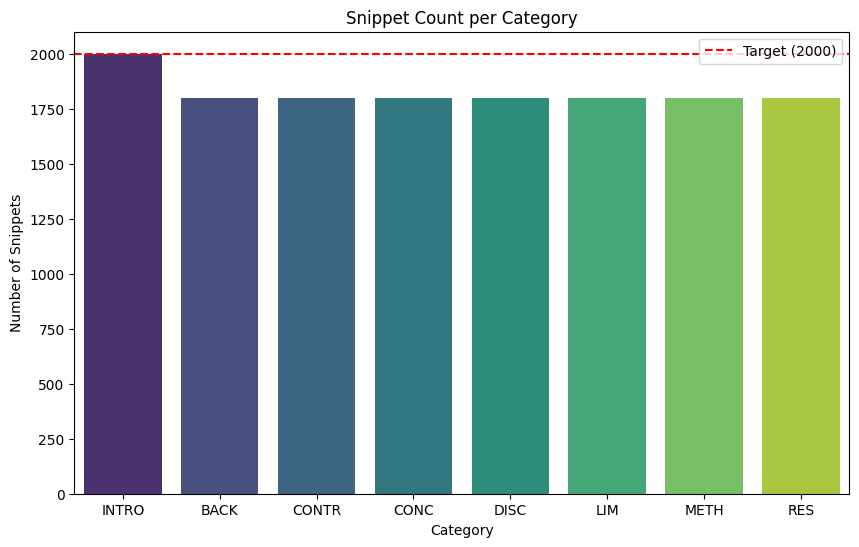


2. WORD COUNT CONSTRAINTS
------------------------------
count    14600.000000
mean       719.137534
std        191.641745
min        250.000000
25%        741.000000
50%        748.000000
75%        750.000000
max       1000.000000
Name: word_count, dtype: float64

SUCCESS: All snippets are strictly within the 250 - 1000 word limit.


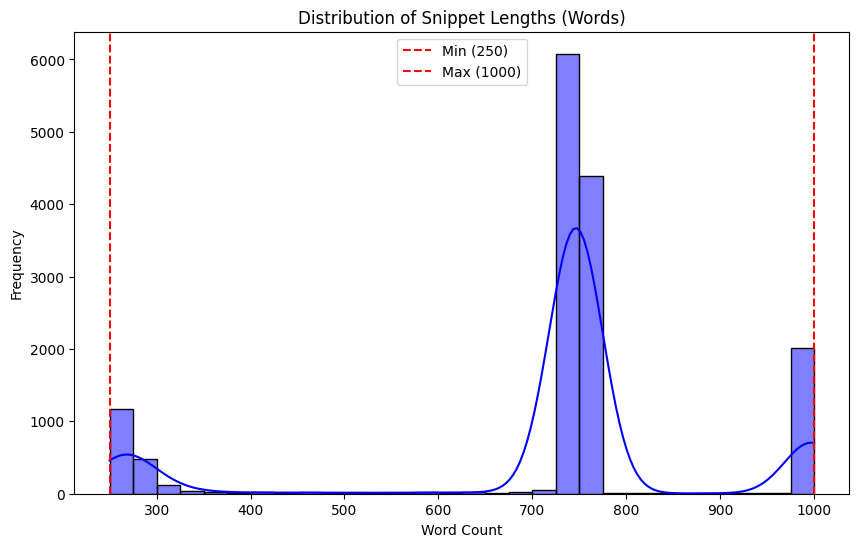


3. REGEX SCORE (CONFIDENCE)
------------------------------
category
BACK     4.24
CONC     2.96
CONTR    0.00
DISC     2.66
INTRO    3.06
LIM      3.06
METH     7.15
RES      6.88
Name: regex_score, dtype: float64

4. WORD COUNT BY CATEGORY (Length Bias Check)
------------------------------


/tmp/ipykernel_587/3573927.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='word_count', palette='Set2')


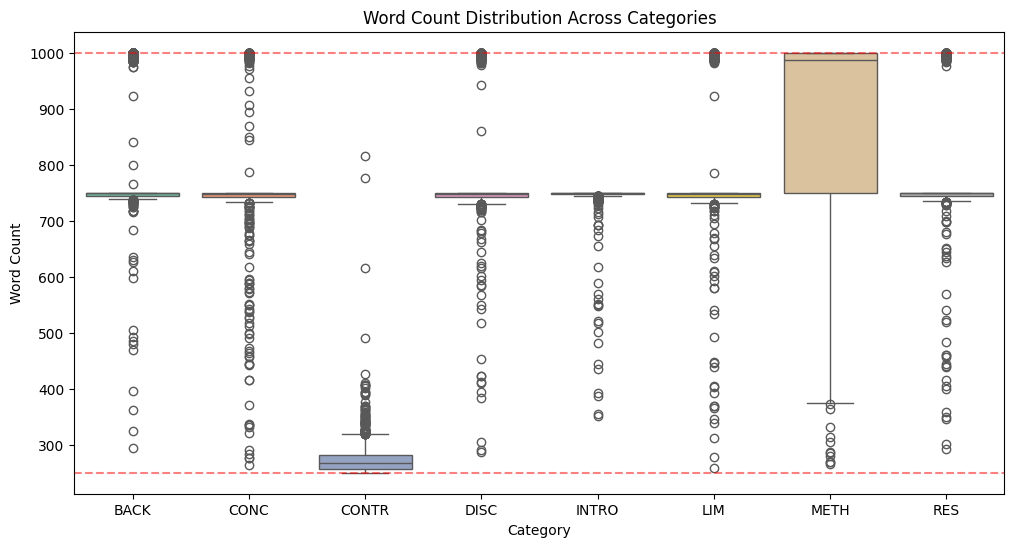


5. KEYWORD DIVERSITY
------------------------------

Top 5 triggers for BACK:
  - 'según el': 646 times
  - 'según la': 566 times
  - 'antecedentes': 475 times
  - 'marco teórico': 292 times
  - 'según los': 256 times

Top 5 triggers for CONC:
  - 'conclusiones': 1086 times
  - 'conclusión': 484 times
  - 'finalmente': 440 times
  - 'se recomienda': 305 times
  - 'se concluye que': 181 times

Top 5 triggers for CONTR:
  - 'trabajo': 127 times
  - 'educación': 118 times
  - 'estudio': 60 times
  - 'investigación': 55 times
  - 'desarrollo': 51 times

Top 5 triggers for DISC:
  - 'discusión': 957 times
  - 'a diferencia de': 251 times
  - 'interpretación de': 205 times
  - 'consecuencia de': 192 times
  - 'a la luz de': 175 times

Top 5 triggers for INTRO:
  - 'introducción': 1691 times
  - 'justificación': 736 times
  - 'objetivo general': 573 times
  - 'planteamiento del problema': 292 times
  - 'objetivo principal': 205 times

Top 5 triggers for LIM:
  - 'falta de': 1092 times
  - 'l

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

def run_eda(input_csv):
    """
    Performs Exploratory Data Analysis on the auto-labeled dataset
    to ensure it meets the project constraints before training.
    """
    try:
        df = pd.read_csv(input_csv)
        print(f"--- EDA REPORT ---")
        print(f"Successfully loaded dataset: {len(df)} total snippets.\n")
    except FileNotFoundError:
        print(f"Error: Could not find {input_csv}")
        return

    # CLASS BALANCE ANALYSIS
    print("1. CLASS DISTRIBUTION")
    print("-" * 30)
    class_counts = df['category'].value_counts()
    print(class_counts)
    print("\n")

    # Plot Class Distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='category', order=class_counts.index, palette='viridis')
    plt.title('Snippet Count per Category')
    plt.ylabel('Number of Snippets')
    plt.xlabel('Category')
    plt.axhline(y=2000, color='r', linestyle='--', label='Target (2000)')
    plt.legend()
    # plt.savefig('eda_class_distribution.png')
    # plt.close()
    # print("-> Saved class distribution plot as 'eda_class_distribution.png'")
    plt.show()

    # WORD COUNT CONSTRAINTS (Crucial for your project)
    print("\n2. WORD COUNT CONSTRAINTS")
    print("-" * 30)
    print(df['word_count'].describe())

    # Check for violations (below 250 or above 1000)
    violations = df[(df['word_count'] < 250) | (df['word_count'] > 1000)]
    if not violations.empty:
        print(f"\nWARNING: Found {len(violations)} snippets that violate the 250-1000 word limit!")
        print("Please check these source files:")
        print(violations[['source_file', 'category', 'word_count']].head())
    else:
        print("\nSUCCESS: All snippets are strictly within the 250 - 1000 word limit.")

    # Plot Word Count Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='word_count', bins=30, kde=True, color='blue')
    plt.title('Distribution of Snippet Lengths (Words)')
    plt.xlabel('Word Count')
    plt.ylabel('Frequency')
    plt.axvline(x=250, color='r', linestyle='--', label='Min (250)')
    plt.axvline(x=1000, color='r', linestyle='--', label='Max (1000)')
    plt.legend()
    # plt.savefig('eda_word_count.png')
    # plt.close()
    # print("-> Saved word count distribution plot as 'eda_word_count.png'")
    plt.show()

    # REGEX CONFIDENCE (Are we matching enough words?)
    print("\n3. REGEX SCORE (CONFIDENCE)")
    print("-" * 30)
    avg_score_per_class = df.groupby('category')['regex_score'].mean().round(2)
    print(avg_score_per_class)

    # WORD COUNT BY CATEGORY (Checking for Length Bias)
    print("\n4. WORD COUNT BY CATEGORY (Length Bias Check)")
    print("-" * 30)
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='category', y='word_count', palette='Set2')
    plt.title('Word Count Distribution Across Categories')
    plt.ylabel('Word Count')
    plt.xlabel('Category')
    plt.axhline(y=250, color='r', linestyle='--', alpha=0.5)
    plt.axhline(y=1000, color='r', linestyle='--', alpha=0.5)
    plt.show()

    # KEYWORD DIVERSITY (What is triggering the regex?)
    print("\n5. KEYWORD DIVERSITY")
    print("-" * 30)
    for category in df['category'].unique():
        cat_df = df[df['category'] == category]
        all_kws = []
        for kw_string in cat_df['matched_keywords'].dropna():
            # Split by comma and clean
            kws = [k.strip() for k in kw_string.split(',') if k.strip()]
            all_kws.extend(kws)

        top_kws = Counter(all_kws).most_common(5)
        print(f"\nTop 5 triggers for {category}:")
        for kw, count in top_kws:
            print(f"  - '{kw}': {count} times")

    # DATA INTEGRITY (Duplicates & Nulls)
    print("\n6. DATA INTEGRITY CHECKS")
    print("-" * 30)

    # Check for empty snippets
    null_snippets = df['snippet'].isnull().sum()
    print(f"Null/Empty snippets: {null_snippets}")

    # Check for exact duplicate snippets (could happen if a PDF was read twice)
    duplicate_snippets = df.duplicated(subset=['snippet']).sum()
    print(f"Exact duplicate snippets: {duplicate_snippets}")
    if duplicate_snippets > 0:
        print("  -> Consider dropping duplicates: df.drop_duplicates(subset=['snippet'])")

    # Check for files that accidentally got assigned multiple categories
    # (Our script prevents this, but good to double check)
    files_with_multiple_cats = df.groupby('source_file')['category'].nunique()
    multi_cat_files = files_with_multiple_cats[files_with_multiple_cats > 1].count()
    print(f"Files contributing to more than one category: {multi_cat_files} (Should ideally be low/zero for strict separation)")

    # QUICK AUDIT
    print("\n7. QUICK AUDIT (Top 2 highest scoring snippets)")
    print("-" * 30)
    top_snippets = df.sort_values(by='regex_score', ascending=False).head(2)
    for index, row in top_snippets.iterrows():
        print(f"File: {row['source_file']} | Category: {row['category']}")
        print(f"Keywords Matched: {row['matched_keywords']}")
        print(f"Score: {row['regex_score']}\n")

# ==========================================
# EXECUTION
# ==========================================
# Run this on your output from the auto-labeler
run_eda('training_ready_dataset.csv')  # [MODIFICADO] apunta al dataset combinado y balanceado

# Entrenamiento

## Neutralization Snippets

> 🆕 **Nota** — La neutralizacion se aplica sobre el dataset combinado y balanceado.

In [11]:
def neutralize_snippets(input_csv, output_csv, mask_token="[MASK]"):
    """
    Reads the auto-labeled dataset, finds the matched keywords in the snippet,
    and replaces them with a neutral token to prevent data leakage during training.
    """
    try:
        df = pd.read_csv(input_csv)
        print(f"Loaded dataset with {len(df)} rows.")
    except FileNotFoundError:
        print(f"Error: Could not find {input_csv}")
        return

    # Ensure the required columns exist
    if 'snippet' not in df.columns or 'matched_keywords' not in df.columns:
        print("Error: The CSV must contain 'snippet' and 'matched_keywords' columns.")
        return

    neutralized_snippets = []

    for index, row in df.iterrows():
        original_text = str(row['snippet'])
        keywords_str = str(row['matched_keywords'])

        # If there are no keywords to replace, keep the original text
        if pd.isna(row['matched_keywords']) or not keywords_str.strip():
            neutralized_snippets.append(original_text)
            continue

        # Extract keywords and clean them
        keywords = [k.strip() for k in keywords_str.split(',') if k.strip()]

        # CRITICAL: Sort keywords by length descending!
        # This prevents partial replacements (e.g., replacing "problema" before "problema de investigación")
        keywords.sort(key=len, reverse=True)

        neutralized_text = original_text

        for kw in keywords:
            # Escape regex characters just in case (e.g., if a keyword has a period like "et al.")
            escaped_kw = re.escape(kw)
            # Use word boundaries (\b) so we don't accidentally replace parts of other words
            # Ignore case so it matches "Objetivo" or "OBJETIVO"
            pattern = re.compile(rf'\b{escaped_kw}\b', re.IGNORECASE)
            neutralized_text = pattern.sub(mask_token, neutralized_text)

        neutralized_snippets.append(neutralized_text)

    # Add the new column to the dataframe
    df['neutralized_snippet'] = neutralized_snippets

    # Save the prepared dataset
    df.to_csv(output_csv, index=False, encoding='utf-8')
    print(f"Success! Neutralized dataset saved to {output_csv}")

    # Print a quick sample so you can verify it worked
    print("\n--- Quick Verification Sample ---")
    sample = df[df['matched_keywords'].notna()].head(1)
    if not sample.empty:
        print(f"ORIGINAL: {sample['snippet'].values[0][:150]}...")
        print(f"KEYWORDS: {sample['matched_keywords'].values[0]}")
        print(f"NEUTRALIZED: {sample['neutralized_snippet'].values[0][:150]}...")

    return df
# ==========================================
# EXECUTION
# ==========================================
# Run this AFTER you have generated your auto-labeled CSV from Step 1
neutralized_snippets = neutralize_snippets('training_ready_dataset.csv', 'neutralized_dataset.csv')  # [MODIFICADO] usa el dataset combinado


Loaded dataset with 14600 rows.
Success! Neutralized dataset saved to neutralized_dataset.csv

--- Quick Verification Sample ---
ORIGINAL: Materiales: flores, hojas, molinillo de  viento, vaso con agua, piedras, taza  de cerámica, etc.  Espacio: el aula.  Organización: la actividad se  re...
KEYWORDS: según el, según su, según se
NEUTRALIZED: Materiales: flores, hojas, molinillo de  viento, vaso con agua, piedras, taza  de cerámica, etc.  Espacio: el aula.  Organización: la actividad se  re...


In [12]:
neutralized_snippets

,source_file,category,snippet,word_count,matched_keywords,regex_score,neutralized_snippet
0,109492641.txt,BACK,"Materiales: flores, hojas, molinillo de vient...",996,"según el, según su, según se",3,"Materiales: flores, hojas, molinillo de vient..."
1,68093151.txt,BACK,87 REVISTA CEDOTIC ISSN: 2539-1518 Vol. 3. N...,744,"según lo, estado del arte, según el, según la",4,87 REVISTA CEDOTIC ISSN: 2539-1518 Vol. 3. N...
2,84093969.txt,BACK,pretende resolver la divergencia entre el sign...,730,"según culler, según georges, según eco",3,pretende resolver la divergencia entre el sign...
3,108651798.txt,BACK,"posmodernidad, que entiende como la lógica cul...",743,"según jameson, según francisco, según hartog",3,"posmodernidad, que entiende como la lógica cul..."
4,89671916.txt,BACK,Investigadores de nuevas variedades vegetales ...,493,según el,2,Investigadores de nuevas variedades vegetales ...
...,...,...,...,...,...,...,...
14595,148503555.txt,RES,UNIVERSIDAD CATÓLICA SANTO TORIBIO DE MOGROVEJ...,750,"se identificó, resultados, una disminución de",5,UNIVERSIDAD CATÓLICA SANTO TORIBIO DE MOGROVEJ...
14596,86593291.txt,RES,"tarea o estudiar para un examen. ,450 0.000 ...",740,"resultados, coeficiente de, en la tabla",22,"tarea o estudiar para un examen. ,450 0.000 ..."
14597,85377119.txt,RES,"la encuesta, los docentes manifestaron hábito...",747,"se observó que, se apreció, resultados, hallazgos",5,"la encuesta, los docentes manifestaron hábito..."
14598,7450655.txt,RES,1.29. Sensibilidad a la caída del RevPar en fu...,744,resultados,14,1.29. Sensibilidad a la caída del RevPar en fu...


In [13]:
neutralized_snippets.loc[3, ["neutralized_snippet"]].values

array(['posmodernidad, que entiende como la lógica cultural del capitalismo tardío, es decir, aquel dominado por  la lógica del capital financiero, consolidado tras los Gobiernos neoliberales de Ronald Reagan y Margaret  Thatcher. Esta lógica cultural se caracterizaría, [MASK], por el creciente predominio en nuestras  concepciones de lo espacial sobre lo temporal. Jameson denomina a este fenómeno el fin de la  temporalidad, donde la intensidad del presente hace que el antes y el después desaparezcan; en JAMESON,  Frederic, El postmodernismo revisado, Madrid: Abada, 2012, pp. 20-34.  Introducción   9  ocupándose del estudio de lo social desde el año 1966, en que fue fundado en el Ruskin  College de Oxford, con el objetivo de animar a los trabajadores y trabajadoras a escribir  su propia historia28.  En el mismo sentido de trabajar sobre estas mediaciones simbólicas que solo se  encuentran en el estudio de algunos aspectos de lo social, apunta el historiador Franois  Hartog que los regím

## Train / Validation / Test Split

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split

def create_strict_partitions(manual_csv, auto_neutralized_csv, val_size=0.15):
    """
    Creates Train, Validation, and Test datasets ensuring NO document-level overlap.
    Includes column alignment and string normalization for compatibility with HuggingFace.
    """
    COLS = ['source_file', 'category', 'snippet', 'word_count',
            'matched_keywords', 'regex_score', 'neutralized_snippet']

    print("--- 1. LOADING DATA ---")
    # Load the manually validated data (The Golden Test Set)
    test_df = pd.read_csv(manual_csv)
    print(f"Test Set (Manual): {len(test_df)} snippets loaded.")

    # Align test set columns to match train/val structure
    # (manual labels have different columns than auto-labeled batches)
    test_df['word_count'] = test_df['snippet'].apply(lambda x: len(str(x).split()))
    test_df['matched_keywords'] = test_df['keywords'] if 'keywords' in test_df.columns else ''
    test_df['regex_score'] = 0
    test_df['neutralized_snippet'] = test_df['snippet'].astype(str)
    test_df = test_df[COLS]

    # Load the neutralized auto-labeled data
    auto_df = pd.read_csv(auto_neutralized_csv)
    # Ensure neutralized_snippet has no nulls
    auto_df['neutralized_snippet'] = auto_df['neutralized_snippet'].fillna(
        auto_df['snippet']).astype(str)
    auto_df = auto_df[COLS]
    print(f"Auto-labeled Set: {len(auto_df)} snippets loaded.")

    print("\n--- 2. VERIFYING STRICT ISOLATION ---")
    test_files = set(test_df['source_file'].unique())
    auto_files = set(auto_df['source_file'].unique())
    overlap = test_files.intersection(auto_files)
    if overlap:
        print(f"CRITICAL WARNING: Found {len(overlap)} overlapping files. Removing...")
        auto_df = auto_df[~auto_df['source_file'].isin(overlap)]
    else:
        print("SUCCESS: Zero overlap between Test files and Auto-labeled files.")

    print("\n--- 3. SPLITTING TRAIN AND VALIDATION BY DOCUMENT ---")
    unique_auto_files = auto_df['source_file'].unique()
    train_files, val_files = train_test_split(unique_auto_files, test_size=val_size, random_state=42)
    train_df = auto_df[auto_df['source_file'].isin(train_files)]
    val_df = auto_df[auto_df['source_file'].isin(val_files)]
    print(f"Files allocated -> Train: {len(train_files)} | Validation: {len(val_files)}")
    print(f"Snippets allocated -> Train: {len(train_df)} | Validation: {len(val_df)}")

    print("\n--- 4. SAVING PARTITIONS ---")
    train_df.to_csv('dataset_train.csv', index=False)
    val_df.to_csv('dataset_val.csv', index=False)
    test_df.to_csv('dataset_test.csv', index=False)
    print("All partitions saved! (dataset_train.csv, dataset_val.csv, dataset_test.csv)")

    print("\n--- QUICK BALANCE CHECK (TRAIN SET) ---")
    print(train_df['category'].value_counts())

    return train_df, val_df, test_df

# ==========================================
# EXECUTION
# ==========================================
train_df, val_df, test_df = create_strict_partitions(unified_csv, 'neutralized_dataset.csv')


--- 1. LOADING DATA ---
Test Set (Manual): 1601 snippets loaded.
Auto-labeled Set: 14600 snippets loaded.

--- 2. VERIFYING STRICT ISOLATION ---
SUCCESS: Zero overlap between Test files and Auto-labeled files.

--- 3. SPLITTING TRAIN AND VALIDATION BY DOCUMENT ---
Files allocated -> Train: 8907 | Validation: 1572
Snippets allocated -> Train: 12357 | Validation: 2243

--- 4. SAVING PARTITIONS ---
All partitions saved! (dataset_train.csv, dataset_val.csv, dataset_test.csv)

--- QUICK BALANCE CHECK (TRAIN SET) ---
category
INTRO    1691
METH     1553
RES      1536
CONC     1521
DISC     1520
CONTR    1513
LIM      1512
BACK     1511
Name: count, dtype: int64


## Guardar y Restaurar CSVs desde Drive
> Correr **Guardar** una vez después del Split para no perder los archivos si el entorno se reinicia. La próxima vez correr solo **Restaurar** e ir directo a Fine Tuning.

In [18]:
# ==========================================
# GUARDAR CSVs EN DRIVE (correr una sola vez despues del Split)
# ==========================================
import shutil, os

DRIVE_FOLDER = '/content/drive/MyDrive/maia_datasets'
os.makedirs(DRIVE_FOLDER, exist_ok=True)

for f in ['dataset_train.csv', 'dataset_val.csv', 'dataset_test.csv',
          'neutralized_dataset.csv', 'training_ready_dataset.csv']:
    shutil.copy(f, f"{DRIVE_FOLDER}/{f}")
    print(f"Guardado: {f}")

print("\nTodos los CSVs guardados en Drive correctamente.")


Guardado: dataset_train.csv
Guardado: dataset_val.csv
Guardado: dataset_test.csv
Guardado: neutralized_dataset.csv
Guardado: training_ready_dataset.csv

Todos los CSVs guardados en Drive correctamente.


In [19]:
# ==========================================
# RESTAURAR CSVs DESDE DRIVE
# ==========================================
# Correr esta celda en lugar de todo el pipeline de preparacion
# cuando el entorno se reinicia y los archivos ya estan en Drive.
# ==========================================

import shutil

DRIVE_FOLDER = '/content/drive/MyDrive/maia_datasets'

for f in ['dataset_train.csv', 'dataset_val.csv', 'dataset_test.csv',
          'neutralized_dataset.csv', 'training_ready_dataset.csv']:
    shutil.copy(f"{DRIVE_FOLDER}/{f}", f"./{f}")
    print(f"Restaurado: {f}")

print("\nCSVs listos. Puedes ir directo a Fine Tuning o LLMs.")


Restaurado: dataset_train.csv
Restaurado: dataset_val.csv
Restaurado: dataset_test.csv
Restaurado: neutralized_dataset.csv
Restaurado: training_ready_dataset.csv

CSVs listos. Puedes ir directo a Fine Tuning o LLMs.


In [21]:
# ==========================================
# CONFIGURACION W&B PARA SCIBETO
# ==========================================
# IMPORTANTE: Correr esta celda ANTES del fine-tuning para que
# el run quede en el mismo proyecto que Llama 3 y los demas modelos.
# Sin esto, HuggingFace Trainer crea un proyecto separado llamado "huggingface".
# ==========================================

import os

os.environ["WANDB_PROJECT"] = "maia-flag-document-analysis"
os.environ["WANDB_ENTITY"] = "natamoncada10-universidad-de-los-andes"

print("W&B project configurado: maia-flag-document-analysis")
print("Todos los runs de SciBETO quedaran en el mismo proyecto que Llama 3.")


W&B project configurado: maia-flag-document-analysis
Todos los runs de SciBETO quedaran en el mismo proyecto que Llama 3.


## Fine Tuning de un Encoder

In [22]:
!pip install transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00


In [23]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

# ==========================================
# 1. SETUP AND LABEL MAPPING
# ==========================================
LABELS = ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'CONTR', 'LIM', 'CONC']
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for i, label in enumerate(LABELS)}

MODEL_NAME = "Flaglab/SciBETO-large"

print(f"Loading tokenizer from: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ==========================================
# 2. LOAD AND PREPARE DATASET
# ==========================================
def load_and_prepare_data(train_csv, val_csv, test_csv):
    """
    Carga CSVs con pandas y convierte a HuggingFace Dataset manualmente.
    Evita problemas de schema, cache y NaN que ocurren con load_dataset.
    """
    def load_and_clean(filepath):
        df = pd.read_csv(filepath)
        # Alinear columnas faltantes
        if 'word_count' not in df.columns:
            df['word_count'] = df['snippet'].apply(lambda x: len(str(x).split()))
        if 'matched_keywords' not in df.columns:
            df['matched_keywords'] = ''
        if 'regex_score' not in df.columns:
            df['regex_score'] = 0
        if 'neutralized_snippet' not in df.columns:
            df['neutralized_snippet'] = df['snippet']
        # Forzar tipos correctos y limpiar valores problematicos
        df['neutralized_snippet'] = (
            df['neutralized_snippet']
            .fillna(df['snippet'])
            .astype(str)
            .str.replace('\n', ' ')
            .str.replace('\r', ' ')
            .str.strip()
        )
        df['label'] = df['category'].map(label2id)
        return df[['neutralized_snippet', 'category', 'label']]

    train_df = load_and_clean(train_csv)
    val_df   = load_and_clean(val_csv)
    test_df  = load_and_clean(test_csv)

    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    return DatasetDict({
        'train':      Dataset.from_pandas(train_df, preserve_index=False),
        'validation': Dataset.from_pandas(val_df,   preserve_index=False),
        'test':       Dataset.from_pandas(test_df,  preserve_index=False),
    })

# ==========================================
# 3. TOKENIZATION
# ==========================================
def tokenize_function(examples):
    return tokenizer(
        examples['neutralized_snippet'],
        padding="max_length",
        truncation=True,
        max_length=512
    )

# ==========================================
# 4. EVALUATION METRICS
# ==========================================
f1_metric = evaluate.load("f1")
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    macro_f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")["f1"]
    micro_f1 = f1_metric.compute(predictions=predictions, references=labels, average="micro")["f1"]
    return {"accuracy": accuracy, "f1_macro": macro_f1, "f1_micro": micro_f1}

# ==========================================
# 5. INITIALIZE AND TRAIN MODEL
# ==========================================
def train_model():
    dataset = load_and_prepare_data('dataset_train.csv', 'dataset_val.csv', 'dataset_test.csv')

    print("Tokenizing datasets...")
    tokenized_datasets = dataset.map(tokenize_function, batched=True)

    print("Loading model...")
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LABELS),
        id2label=id2label,
        label2id=label2id
    )

    training_args = TrainingArguments(
        output_dir="./scibeto_finetuned_task1",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        fp16=True,
        report_to="wandb",
        run_name="task1-scibeto-v2"  # <- cambiar por nombre del integrante
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        compute_metrics=compute_metrics,
    )

    print("Starting fine-tuning...")
    trainer.train()

    print("Evaluating on the completely unseen Test Set...")
    test_results = trainer.evaluate(eval_dataset=tokenized_datasets["test"])
    print("\n--- FINAL TEST RESULTS ---")
    print(test_results)

    trainer.save_model("./scibeto_final_model")
    print("Model saved to ./scibeto_final_model")

train_model()


Loading tokenizer from: Flaglab/SciBETO-large


config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/378 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Evaluating on the completely unseen Test Set...



--- FINAL TEST RESULTS ---
{'eval_loss': 4.197513580322266, 'eval_accuracy': 0.1930043722673329, 'eval_f1_macro': 0.15778170656459267, 'eval_f1_micro': 0.1930043722673329, 'eval_runtime': 7.0578, 'eval_samples_per_second': 226.843, 'eval_steps_per_second': 28.479, 'epoch': 3.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./scibeto_final_model


## LLMs de Pesos Abiertos

In [25]:
!pip install transformers accelerate bitsandbytes pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.7 MB/s eta 0:00:00


In [26]:
import pandas as pd
import torch
import re
import wandb
from google.colab import userdata
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sklearn.metrics import accuracy_score, f1_score
from huggingface_hub import login

# ==========================================
# 0. AUTENTICACION HUGGINGFACE
# ==========================================
# IMPORTANTE: Agregar token en Colab Secrets
# Nombre del secret: HF_TOKEN
# Valor: token de https://huggingface.co/settings/tokens
login(token=userdata.get("HF_TOKEN"))

# ==========================================
# 1. SETUP MODELO Y CUANTIZACION (4-BIT)
# ==========================================
MODEL_ID = "meta-llama/Meta-Llama-3-8B-Instruct"

print(f"Loading {MODEL_ID} in 4-bit precision...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)

# ==========================================
# 2. PROMPT ENGINEERING (ZERO-SHOT)
# ==========================================
def create_prompt(snippet):
    system_prompt = """Eres un asistente experto en analizar articulos cientificos en espanol.
Tu tarea es clasificar el siguiente fragmento de texto en EXACTAMENTE UNA de estas 8 categorias:
- INTRO: Introduccion, motivacion, objetivos.
- BACK: Antecedentes, trabajos previos, estado del arte.
- METH: Metodologia, diseno experimental, materiales.
- RES: Resultados obtenidos empiricamente.
- DISC: Discusion, interpretacion de resultados.
- CONTR: Contribuciones cientificas o aportes originales.
- LIM: Limitaciones del estudio.
- CONC: Conclusiones y trabajo futuro.

Reglas estrictas:
1. Analiza el texto cuidadosamente.
2. Responde UNICAMENTE con la sigla de la categoria (ejemplo: INTRO, METH, DISC).
3. No incluyas ninguna otra palabra, explicacion o puntuacion."""

    user_prompt = f"Fragmento a clasificar:\n\n{snippet}\n\nCategoria:"

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

# ==========================================
# 3. PARSING SALIDA DEL LLM
# ==========================================
def extract_category(llm_response):
    valid_categories = ["INTRO", "BACK", "METH", "RES", "DISC", "CONTR", "LIM", "CONC"]
    response_upper = llm_response.upper()
    for cat in valid_categories:
        if re.search(rf"\b{cat}\b", response_upper):
            return cat
    return "UNKNOWN"

# ==========================================
# 4. EVALUACION SOBRE EL TEST SET
# ==========================================
def evaluate_local_llm(test_csv, run_name="task1-llama3-v1"):
    # --- Iniciar W&B ---
    wandb.init(
        project="maia-flag-document-analysis",
        entity="natamoncada10-universidad-de-los-andes",
        name=run_name,
        config={
            "model": MODEL_ID,
            "strategy": "zero-shot",
            "quantization": "4-bit NF4",
            "temperature": 0.0,
            "max_new_tokens": 10
        }
    )

    try:
        df_test = pd.read_csv(test_csv)
        print(f"Loaded Test Set: {len(df_test)} snippets.\n")
    except FileNotFoundError:
        print(f"Error: Could not find {test_csv}")
        wandb.finish()
        return

    predictions = []
    actuals = []

    for index, row in df_test.iterrows():
        snippet = row["neutralized_snippet"]
        actual_label = row["category"]

        prompt = create_prompt(snippet)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.0,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

        input_length = inputs["input_ids"].shape[1]
        generated_tokens = outputs[0][input_length:]
        raw_response = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
        predicted_label = extract_category(raw_response)

        predictions.append(predicted_label)
        actuals.append(actual_label)

        if (index + 1) % 50 == 0:
            print(f"Processed {index + 1}/{len(df_test)}...")

    # --- Calcular metricas ---
    print("\n--- INFERENCE COMPLETE ---")
    VALID_LABELS = ["INTRO", "BACK", "METH", "RES", "DISC", "CONTR", "LIM", "CONC"]
    df_results = pd.DataFrame({"Actual": actuals, "Predicted": predictions})

    accuracy = accuracy_score(df_results["Actual"], df_results["Predicted"])
    macro_f1 = f1_score(df_results["Actual"], df_results["Predicted"], average="macro", labels=VALID_LABELS)
    micro_f1 = f1_score(df_results["Actual"], df_results["Predicted"], average="micro", labels=VALID_LABELS)
    unknown_count = (df_results["Predicted"] == "UNKNOWN").sum()

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Macro F1:  {macro_f1:.4f}")
    print(f"Micro F1:  {micro_f1:.4f}")
    print(f"UNKNOWN:   {unknown_count} predicciones no reconocidas")

    # --- Registrar en W&B ---
    wandb.log({
        "accuracy": accuracy,
        "f1_macro": macro_f1,
        "f1_micro": micro_f1,
        "unknown_predictions": unknown_count
    })

    df_results.to_csv("llm_inference_results.csv", index=False)
    print("Saved raw predictions to llm_inference_results.csv")

    wandb.finish()
    return df_results

# ==========================================
# EJECUCION
# ==========================================
# IMPORTANTE: Cambia el run_name antes de correr
evaluate_local_llm("dataset_test.csv", run_name="task1-llama3-v2")


Loading meta-llama/Meta-Llama-3-8B-Instruct in 4-bit precision...


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

...

eval/accuracy,███▁
eval/f1_macro,███▁
eval/f1_micro,███▁
eval/loss,▁▁▁█
eval/runtime,▇█▇▁
eval/samples_per_second,█▆▇▁
eval/steps_per_second,█▅▇▁
train/epoch,▁▂▃▃▄▄▅▅▆▇████
train/global_step,▁▂▃▃▄▄▅▅▆▇████
train/grad_norm,▂▁▁▂▁█▂▅▁
+2,...


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loaded Test Set: 1601 snippets.

Processed 50/1601...
Processed 100/1601...
Processed 150/1601...
Processed 200/1601...
Processed 250/1601...
Processed 300/1601...
Processed 350/1601...
Processed 400/1601...
Processed 450/1601...
Processed 500/1601...
Processed 550/1601...
Processed 600/1601...
Processed 650/1601...
Processed 700/1601...
Processed 750/1601...
Processed 800/1601...
Processed 850/1601...
Processed 900/1601...
Processed 950/1601...
Processed 1000/1601...
Processed 1050/1601...
Processed 1100/1601...
Processed 1150/1601...
Processed 1200/1601...
Processed 1250/1601...
Processed 1300/1601...
Processed 1350/1601...
Processed 1400/1601...
Processed 1450/1601...
Processed 1500/1601...
Processed 1550/1601...
Processed 1600/1601...

--- INFERENCE COMPLETE ---
Accuracy:  0.3004
Macro F1:  0.2394
Micro F1:  0.3004
UNKNOWN:   0 predicciones no reconocidas
Saved raw predictions to llm_inference_results.csv


accuracy,▁
f1_macro,▁
f1_micro,▁
unknown_predictions,▁
accuracy,0.30044
f1_macro,0.23945
f1_micro,0.30044
unknown_predictions,0


,Actual,Predicted
0,CONC,DISC
1,CONC,INTRO
2,CONC,INTRO
3,CONC,INTRO
4,CONC,METH
...,...,...
1596,METH,RES
1597,METH,METH
1598,METH,METH
1599,METH,METH


## LLMs Comerciales (OpenAI)

In [20]:
# ==========================================
# LLMs COMERCIALES — GPT-4o-mini Zero-shot
# ==========================================

!pip install openai -q

import pandas as pd
import re
import wandb
from openai import OpenAI
from sklearn.metrics import accuracy_score, f1_score
from google.colab import userdata

# ==========================================
# 0. CONFIGURACIÓN
# ==========================================
# IMPORTANTE: Agregar API key en Colab Secrets con el nombre OPENAI_API_KEY
client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

MODEL_GPT = "gpt-4o-mini"

# ==========================================
# 1. PROMPT (mismo sistema que Llama 3 para comparación justa)
# ==========================================
SYSTEM_PROMPT = """Eres un asistente experto en analizar articulos cientificos en espanol.
Tu tarea es clasificar el siguiente fragmento de texto en EXACTAMENTE UNA de estas 8 categorias:
- INTRO: Introduccion, motivacion, objetivos.
- BACK: Antecedentes, trabajos previos, estado del arte.
- METH: Metodologia, diseno experimental, materiales.
- RES: Resultados obtenidos empiricamente.
- DISC: Discusion, interpretacion de resultados.
- CONTR: Contribuciones cientificas o aportes originales.
- LIM: Limitaciones del estudio.
- CONC: Conclusiones y trabajo futuro.

Reglas estrictas:
1. Analiza el texto cuidadosamente.
2. Responde UNICAMENTE con la sigla de la categoria (ejemplo: INTRO, METH, DISC).
3. No incluyas ninguna otra palabra, explicacion o puntuacion."""

def create_gpt_prompt(snippet):
    return f"Fragmento a clasificar:\n\n{snippet}\n\nCategoria:"

# ==========================================
# 2. PARSING (igual que Llama 3)
# ==========================================
def extract_category_gpt(response_text):
    valid_categories = ["INTRO", "BACK", "METH", "RES", "DISC", "CONTR", "LIM", "CONC"]
    response_upper = response_text.upper()
    for cat in valid_categories:
        if re.search(rf"\b{cat}\b", response_upper):
            return cat
    return "UNKNOWN"

# ==========================================
# 3. EVALUACIÓN SOBRE EL TEST SET
# ==========================================
def evaluate_gpt(test_csv, run_name="task1-gpt4omini-v2"):
    wandb.init(
        project="maia-flag-document-analysis",
        entity="natamoncada10-universidad-de-los-andes",
        name=run_name,
        config={
            "model": MODEL_GPT,
            "strategy": "zero-shot",
            "temperature": 0.0,
            "max_tokens": 10,
            "dataset_version": "v2"
        }
    )

    df_test = pd.read_csv(test_csv)
    print(f"Test set cargado: {len(df_test)} snippets\n")

    predictions = []
    actuals = []
    costs_tokens = {"prompt": 0, "completion": 0}

    for index, row in df_test.iterrows():
        snippet = str(row["neutralized_snippet"])
        actual_label = row["category"]

        response = client.chat.completions.create(
            model=MODEL_GPT,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user",   "content": create_gpt_prompt(snippet)}
            ],
            temperature=0.0,
            max_tokens=10
        )

        raw_response = response.choices[0].message.content.strip()
        predicted_label = extract_category_gpt(raw_response)

        predictions.append(predicted_label)
        actuals.append(actual_label)

        # Acumular tokens para estimar costo
        costs_tokens["prompt"]     += response.usage.prompt_tokens
        costs_tokens["completion"] += response.usage.completion_tokens

        if (index + 1) % 50 == 0:
            print(f"Procesados {index + 1}/{len(df_test)}...")

    # ==========================================
    # 4. MÉTRICAS
    # ==========================================
    VALID_LABELS = ["INTRO", "BACK", "METH", "RES", "DISC", "CONTR", "LIM", "CONC"]
    df_results = pd.DataFrame({"Actual": actuals, "Predicted": predictions})

    accuracy  = accuracy_score(df_results["Actual"], df_results["Predicted"])
    macro_f1  = f1_score(df_results["Actual"], df_results["Predicted"], average="macro",  labels=VALID_LABELS)
    micro_f1  = f1_score(df_results["Actual"], df_results["Predicted"], average="micro",  labels=VALID_LABELS)
    unknown_n = (df_results["Predicted"] == "UNKNOWN").sum()

    # Estimación de costo (precios gpt-4o-mini a mayo 2025)
    cost_usd = (costs_tokens["prompt"] / 1_000_000 * 0.15) + \
               (costs_tokens["completion"] / 1_000_000 * 0.60)

    print(f"\n--- RESULTADOS GPT ---")
    print(f"Accuracy:          {accuracy:.4f}")
    print(f"F1 Macro:          {macro_f1:.4f}")
    print(f"F1 Micro:          {micro_f1:.4f}")
    print(f"UNKNOWN:           {unknown_n}")
    print(f"Tokens (prompt):   {costs_tokens['prompt']:,}")
    print(f"Tokens (comp.):    {costs_tokens['completion']:,}")
    print(f"Costo estimado:    ${cost_usd:.4f} USD")

    wandb.log({
        "accuracy": accuracy,
        "f1_macro": macro_f1,
        "f1_micro": micro_f1,
        "unknown_predictions": unknown_n,
        "prompt_tokens": costs_tokens["prompt"],
        "completion_tokens": costs_tokens["completion"],
        "estimated_cost_usd": cost_usd
    })

    df_results.to_csv("gpt_inference_results.csv", index=False)
    print("Predicciones guardadas en gpt_inference_results.csv")

    wandb.finish()
    return df_results

# ==========================================
# EJECUCIÓN
# ==========================================
gpt_results = evaluate_gpt("dataset_test.csv", run_name="task1-gpt4omini-v2")

wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai


Test set cargado: 1601 snippets

Procesados 50/1601...
Procesados 100/1601...
Procesados 150/1601...
Procesados 200/1601...
Procesados 250/1601...
Procesados 300/1601...
Procesados 350/1601...
Procesados 400/1601...
Procesados 450/1601...
Procesados 500/1601...
Procesados 550/1601...
Procesados 600/1601...
Procesados 650/1601...
Procesados 700/1601...
Procesados 750/1601...
Procesados 800/1601...
Procesados 850/1601...
Procesados 900/1601...
Procesados 950/1601...
Procesados 1000/1601...
Procesados 1050/1601...
Procesados 1100/1601...
Procesados 1150/1601...
Procesados 1200/1601...
Procesados 1250/1601...
Procesados 1300/1601...
Procesados 1350/1601...
Procesados 1400/1601...
Procesados 1450/1601...
Procesados 1500/1601...
Procesados 1550/1601...
Procesados 1600/1601...

--- RESULTADOS GPT ---
Accuracy:          0.4347
F1 Macro:          0.3935
F1 Micro:          0.4347
UNKNOWN:           0
Tokens (prompt):   1,017,380
Tokens (comp.):    2,025
Costo estimado:    $0.1538 USD
Prediccione

accuracy,▁
completion_tokens,▁
estimated_cost_usd,▁
f1_macro,▁
f1_micro,▁
prompt_tokens,▁
unknown_predictions,▁
accuracy,0.43473
completion_tokens,2025
estimated_cost_usd,0.15382
f1_macro,0.39355


# Análisis de Resultados

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

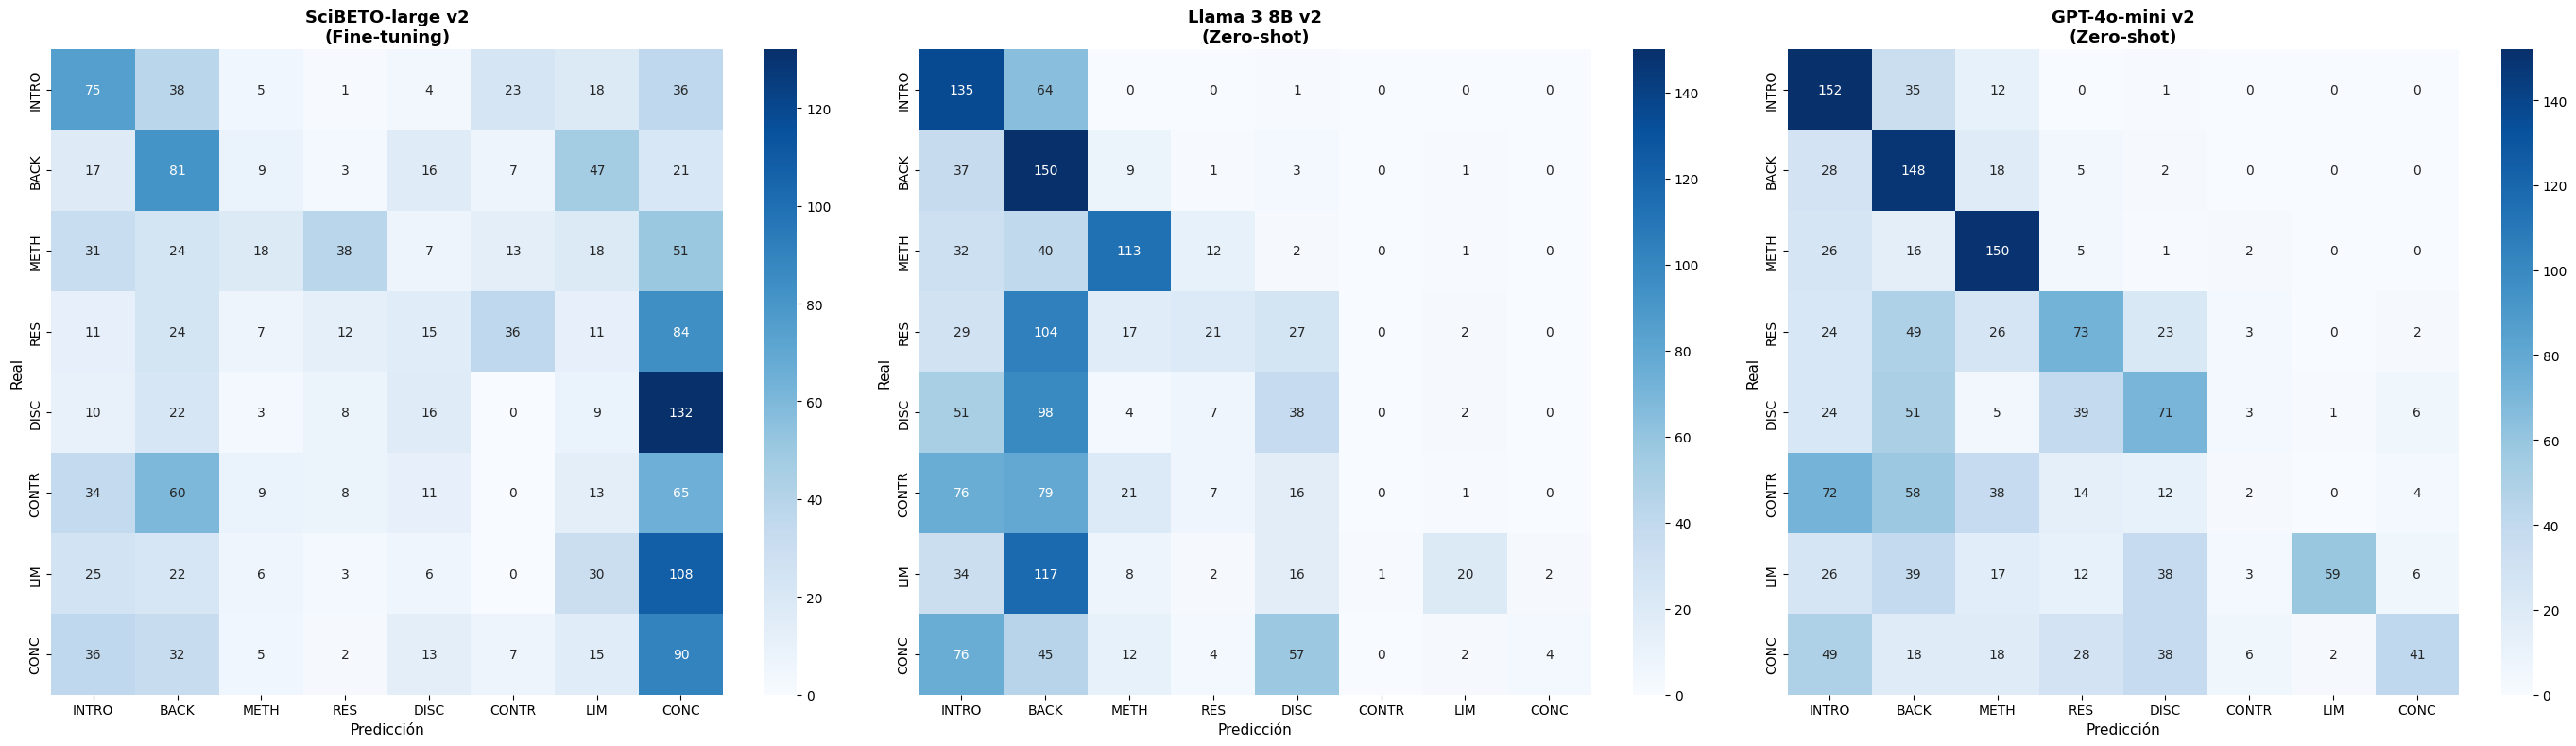

Guardado como confusion_matrices_3models.png

=== SCIBETO v2 — Reporte por categoría ===
              precision    recall  f1-score   support

       INTRO       0.31      0.38      0.34       200
        BACK       0.27      0.40      0.32       201
        METH       0.29      0.09      0.14       200
         RES       0.16      0.06      0.09       200
        DISC       0.18      0.08      0.11       200
       CONTR       0.00      0.00      0.00       200
         LIM       0.19      0.15      0.17       200
        CONC       0.15      0.45      0.23       200

    accuracy                           0.20      1601
   macro avg       0.19      0.20      0.17      1601
weighted avg       0.19      0.20      0.17      1601


=== LLAMA 3 8B v2 — Reporte por categoría ===
              precision    recall  f1-score   support

       INTRO       0.29      0.68      0.40       200
        BACK       0.22      0.75      0.33       201
        METH       0.61      0.56      0.59       

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

LABELS = ['INTRO', 'BACK', 'METH', 'RES', 'DISC', 'CONTR', 'LIM', 'CONC']

# --- Cargar predicciones ---
llama_df   = pd.read_csv('./llm_inference_results.csv')
gpt_df     = pd.read_csv('./gpt_inference_results.csv')

# --- Generar predicciones de SciBETO sobre el test set ---
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "./scibeto_final_model"
tokenizer  = AutoTokenizer.from_pretrained("Flaglab/SciBETO-large")
model      = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

test_df  = pd.read_csv('./dataset_test.csv')
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for i, label in enumerate(LABELS)}

scibeto_preds = []
for _, row in test_df.iterrows():
    inputs = tokenizer(
        str(row['neutralized_snippet']),
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding="max_length"
    ).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    pred_id = outputs.logits.argmax(-1).item()
    scibeto_preds.append(id2label[pred_id])

scibeto_df = pd.DataFrame({
    'Actual':    test_df['category'].tolist(),
    'Predicted': scibeto_preds
})
scibeto_df.to_csv('scibeto_inference_results.csv', index=False)

# --- Matrices de confusión (3 modelos) ---
fig, axes = plt.subplots(1, 3, figsize=(28, 8))

for ax, df, title in [
    (axes[0], scibeto_df, 'SciBETO-large v2\n(Fine-tuning)'),
    (axes[1], llama_df,   'Llama 3 8B v2\n(Zero-shot)'),
    (axes[2], gpt_df,     'GPT-4o-mini v2\n(Zero-shot)')
]:
    cm = confusion_matrix(df['Actual'], df['Predicted'], labels=LABELS)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABELS, yticklabels=LABELS,
        ax=ax, cbar=True
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices_3models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado como confusion_matrices_3models.png")

# --- Reporte por categoría ---
print("\n=== SCIBETO v2 — Reporte por categoría ===")
print(classification_report(scibeto_df['Actual'], scibeto_df['Predicted'], labels=LABELS))

print("\n=== LLAMA 3 8B v2 — Reporte por categoría ===")
print(classification_report(llama_df['Actual'], llama_df['Predicted'], labels=LABELS))

print("\n=== GPT-4o-mini v2 — Reporte por categoría ===")
print(classification_report(gpt_df['Actual'], gpt_df['Predicted'], labels=LABELS))

In [31]:
from google.colab import files
files.download('dataset_train.csv')
files.download('dataset_val.csv')
files.download('dataset_test.csv')
files.download('scibeto_inference_results.csv')
files.download('gpt_inference_results.csv')
files.download('llm_inference_results.csv')
files.download('confusion_matrices_3models.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>